# Model: Isolation Forest
Training an anomaly detection model for fraud detection.

In [1]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import sys
import os

sys.path.append(os.path.abspath('..'))

In [2]:
from src.train_isolation_forest import train_isolation_forest

# Train the model
train_isolation_forest(data_path='../data/processed/train.csv', model_path='../models/isolation_forest.pkl')

Loading training data...
Training Isolation Forest...
Model saved to ../models/isolation_forest.pkl


In [3]:
# Load Test Data
df_test = pd.read_csv('../data/processed/test.csv')
X_test = df_test.drop('Class', axis=1)
y_test = df_test['Class']

In [4]:
# Load and Evaluate the Model
with open('../models/isolation_forest.pkl', 'rb') as f:
    model = pickle.load(f)

# Predict (-1 for outliers, 1 for inliers)
y_pred = model.predict(X_test)
y_pred[y_pred == 1] = 0
y_pred[y_pred == -1] = 1

print('Isolation Forest Results:')
print(classification_report(y_test, y_pred))

Isolation Forest Results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.36      0.37      0.36        98

    accuracy                           1.00     56962
   macro avg       0.68      0.68      0.68     56962
weighted avg       1.00      1.00      1.00     56962



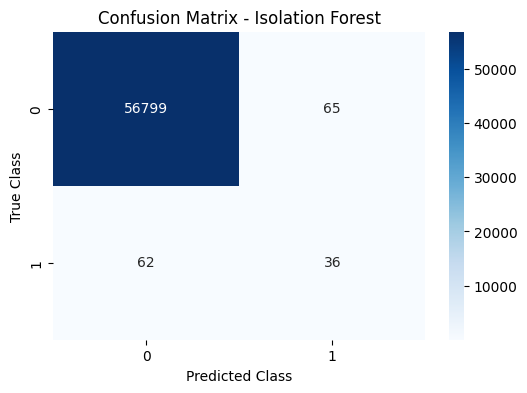

In [5]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Isolation Forest')
plt.ylabel('True Class')
plt.xlabel('Predicted Class')
plt.show()